# Formativa 1: IBM HR Employee Attrition
Coloca el CSV y este notebook en la misma carpeta. Ejecuta de arriba hacia abajo con pandas, numpy, scipy, matplotlib y seaborn.
Pregunta: ¿Qué asociaciones presentan horas extra, ingresos, satisfacción y antigüedad con la salida de empleados?
Los datos son sintéticos. Intervalos y pruebas son ejercicios bajo un modelo de observaciones independientes; no se generalizan a una empresa real ni establecen causalidad.

In [3]:
%pip install pandas numpy scipy matplotlib seaborn

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------------------------------------- - 9.4/9.9 MB 45.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 36.1 MB/s  0:00:00
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --------------------- ------------------ 19.7/36.6 MB 95.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 100.8 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 M

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
original = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(original.shape)
print(original.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

## 1. Calidad
Comprobar faltantes, duplicados y columnas constantes. Conservar EmployeeNumber para trazabilidad; excluirlo del análisis numérico.

In [5]:
print('Faltantes:',original.isna().sum().sum())
print('Duplicados:',original.duplicated().sum())
constantes = original.columns[original.nunique().eq(1)].tolist()
print('Constantes:',constantes)
print(original.Attrition.value_counts())

Faltantes: 0
Duplicados: 0
Constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Attrition
No     1233
Yes     237
Name: count, dtype: int64


## 2. Clasificación de las 35 variables
Los números de satisfacción y educación son ordinales. Edad y duraciones se clasifican por su registro en años enteros. Importes tratados como continuos aunque redondeados; verificar unidades monetarias y de distancia. BusinessTravel nominal, con orden de frecuencia posible para visualización.

In [6]:
nominales = ['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
ordinales = ['Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance']
continuas = ['DailyRate','HourlyRate','MonthlyIncome','MonthlyRate']
def tipo(c):
    if c=='EmployeeNumber': return 'Identificador nominal'
    if c in constantes: return 'Constante'
    if c in nominales: return 'Cualitativa nominal'
    if c in ordinales: return 'Cualitativa ordinal'
    if c in continuas: return 'Cuantitativa tratada como continua'
    if c in ['DistanceFromHome','PercentSalaryHike']: return 'Cuantitativa medida, registrada en enteros'
    return 'Cuantitativa discreta: conteo o años enteros'
diccionario = pd.DataFrame({'Variable':original.columns,'Tipo':[tipo(c) for c in original.columns]})
print(diccionario.to_string(index=False))

                Variable                                         Tipo
                     Age Cuantitativa discreta: conteo o años enteros
               Attrition                          Cualitativa nominal
          BusinessTravel                          Cualitativa nominal
               DailyRate           Cuantitativa tratada como continua
              Department                          Cualitativa nominal
        DistanceFromHome   Cuantitativa medida, registrada en enteros
               Education                          Cualitativa ordinal
          EducationField                          Cualitativa nominal
           EmployeeCount                                    Constante
          EmployeeNumber                        Identificador nominal
 EnvironmentSatisfaction                          Cualitativa ordinal
                  Gender                          Cualitativa nominal
              HourlyRate           Cuantitativa tratada como continua
          JobInvolve

## 3. Faltantes artificiales MCAR
Apunte: generar 10–15 % en una o dos variables numéricas. Usamos 10 % en ingreso y distancia, semilla 42, selección sin reemplazo independiente de los valores. Se parte siempre del original; se reservan los valores retirados para futuras imputaciones. Aquí analizamos observados, sin imputar, e informamos n efectivo.

In [7]:
df = original.copy(deep=True)
rng = np.random.default_rng(42)
reservados = []
for c in ['MonthlyIncome','DistanceFromHome']:
    idx = rng.choice(df.index.to_numpy(),round(len(df)*0.10),replace=False)
    reservados.append(pd.DataFrame({'EmployeeNumber':original.loc[idx,'EmployeeNumber'].to_numpy(),'variable':c,'valor_original':original.loc[idx,c].to_numpy()}))
    df[c] = df[c].astype(float)
    df.loc[idx,c] = np.nan
valores_reservados = pd.concat(reservados,ignore_index=True)
analisis = df.drop(columns=constantes+['EmployeeNumber'])
print(df.isna().sum().loc[lambda x:x.gt(0)])

DistanceFromHome    147
MonthlyIncome       147
dtype: int64


## 4. Descriptiva
Media y mediana describen centro; desviación y cuartiles, dispersión. Para ordinales usar frecuencias y mediana, sin asumir distancias iguales entre niveles.

In [8]:
variables = ['Age','MonthlyIncome','DistanceFromHome','YearsAtCompany','TotalWorkingYears']
print(analisis[variables].describe().T.round(2))
print('Asimetría:',analisis[variables].skew())
print(analisis.groupby('Attrition')[variables].agg(['count','mean','median','std']).round(2))
for c in ['Attrition','OverTime','JobSatisfaction','Department']:
    f=analisis[c].value_counts().sort_index()
    print(c,pd.DataFrame({'n':f,'%':100*f/len(analisis)}).round(2))

                    count     mean      std     min     25%     50%     75%  \
Age                1470.0    36.92     9.14    18.0    30.0    36.0    43.0   
MonthlyIncome      1323.0  6530.21  4708.33  1009.0  2930.5  4960.0  8404.0   
DistanceFromHome   1323.0     9.18     8.09     1.0     2.0     7.0    14.0   
YearsAtCompany     1470.0     7.01     6.13     0.0     3.0     5.0     9.0   
TotalWorkingYears  1470.0    11.28     7.78     0.0     6.0    10.0    15.0   

                       max  
Age                   60.0  
MonthlyIncome      19999.0  
DistanceFromHome      29.0  
YearsAtCompany        40.0  
TotalWorkingYears     40.0  
Asimetría: Age                  0.413286
MonthlyIncome        1.356830
DistanceFromHome     0.951594
YearsAtCompany       1.764529
TotalWorkingYears    1.117172
dtype: float64
            Age                     MonthlyIncome                            \
          count   mean median   std         count     mean  median      std   
Attrition        

## 5. Gráficos
Barras para categorías; histogramas para distribuciones; cajas para comparar grupos. Tasas calculadas dentro de cada grupo.

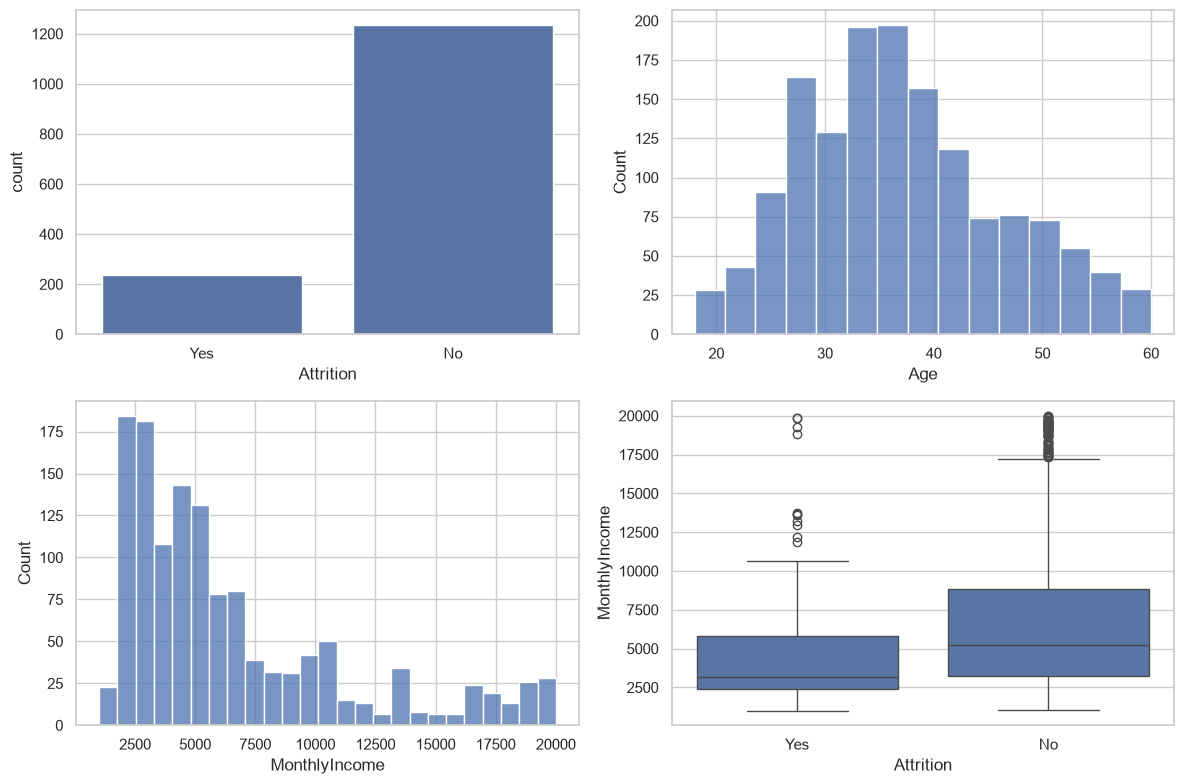

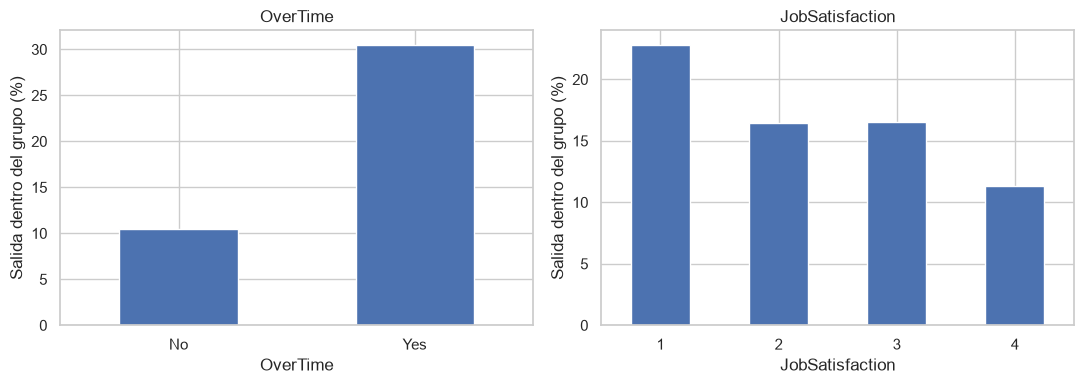

In [9]:
sns.set_theme(style='whitegrid')
fig,axes=plt.subplots(2,2,figsize=(12,8))
sns.countplot(data=analisis,x='Attrition',ax=axes[0,0])
sns.histplot(data=analisis,x='Age',bins=15,ax=axes[0,1])
sns.histplot(data=analisis,x='MonthlyIncome',bins=25,ax=axes[1,0])
sns.boxplot(data=analisis,x='Attrition',y='MonthlyIncome',ax=axes[1,1])
plt.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,c in zip(axes,['OverTime','JobSatisfaction']):
    tasas=analisis.assign(salida=analisis.Attrition.eq('Yes')).groupby(c).salida.mean()*100
    tasas.plot.bar(ax=ax,rot=0)
    ax.set_ylabel('Salida dentro del grupo (%)')
    ax.set_title(c)
plt.tight_layout();plt.show()

## 6. Estimación e intervalos del 95 %
Wilson para proporción y t para ingreso medio (desviación poblacional desconocida, aproximación por tamaño muestral). Revisar asimetría. La proporción del archivo es exacta; el IC ilustra muestreo hipotético del proceso sintético. No estima parámetros de una empresa real. Bajo supuestos, el procedimiento cubre el parámetro en 95 % de repeticiones.

In [10]:
n=len(analisis)
k=analisis.Attrition.eq('Yes').sum()
p=k/n
z=stats.norm.ppf(0.975)
den=1+z*z/n
centro=(p+z*z/(2*n))/den
margen=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
print(f'Salida: {k}/{n} = {p:.2%}; IC Wilson:',(centro-margen,centro+margen))
x=analisis.MonthlyIncome.dropna()
print('Ingreso n:',len(x),'media:',x.mean(),'IC t:',stats.t.interval(0.95,len(x)-1,loc=x.mean(),scale=stats.sem(x)))

Salida: 237/1470 = 16.12%; IC Wilson: (np.float64(0.1433125454143761), np.float64(0.18090242082971547))
Ingreso n: 1323 media: 6530.209372637944 IC t: (np.float64(6276.2682573255615), np.float64(6784.150487950327))


## 7. Hipótesis
H0: horas extra y salida independientes. H1: asociación. α=0,05. Chi-cuadrado de Pearson sin corrección de continuidad. Verificar esperadas ≥5. Independencia entre registros asumida, no probada por identificadores. V de Cramér indica intensidad. Análisis exploratorio bivariado sin ajustar por otros factores.

In [11]:
tabla=pd.crosstab(analisis.OverTime,analisis.Attrition).reindex(index=['No','Yes'],columns=['No','Yes'])
chi2,pvalor,gl,esperadas=stats.chi2_contingency(tabla,correction=False)
v=np.sqrt(chi2/(tabla.to_numpy().sum()*min(tabla.shape[0]-1,tabla.shape[1]-1)))
print(tabla)
print('Esperadas:',esperadas,'mínimo:',esperadas.min())
print(f'Chi2={chi2:.4f}; gl={gl}; p={pvalor:.6g}; V={v:.4f}')
print('Rechazar H0' if pvalor<0.05 else 'No rechazar H0')
print('Salida por grupo (%):',100*tabla.Yes/tabla.sum(axis=1))

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127
Esperadas: [[884.06938776 169.93061224]
 [348.93061224  67.06938776]] mínimo: 67.06938775510204
Chi2=89.0439; gl=1; p=3.86152e-21; V=0.2461
Rechazar H0
Salida por grupo (%): OverTime
No     10.436433
Yes    30.528846
dtype: float64


## 8. Interpretación y entrega
Reportar desbalance (no tasa anual: no hay período definido), centro/dispersión, IC/método/n, hipótesis/α/estadístico/gl/p/V. Asociación no es causalidad. Significancia no es utilidad práctica y p no es probabilidad de H0. Explicar datos sintéticos y MCAR.
PDF: portada, contexto y ficha, preparación, descriptiva/gráficos, estimación, hipótesis, conclusiones/limitaciones, referencias. El notebook respalda trazabilidad. Publicar en foro y comentar dos trabajos leídos: participación aún pendiente.
Fuentes: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset ; https://github.com/jpmaidana/MCDI501-202682 ; apunte de datasets y sesión del 6 de octubre de 2026.

## 9. Guardado opcional
Activar solo si se desean archivos para continuidad. No sobrescribe el original.

In [12]:
GUARDAR = False
if GUARDAR:
    from pathlib import Path
    destino=Path('resultados_formativa1');destino.mkdir(exist_ok=True)
    df.to_csv(destino/'ibm_hr_mcar.csv',index=False)
    valores_reservados.to_csv(destino/'valores_reservados.csv',index=False)
    diccionario.to_csv(destino/'diccionario.csv',index=False)